## 练习1

In [1]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("penguins.csv")

# 总体统计
print("=== Overall bill_length_mm ===")
print(f"Mean: {df['bill_length_mm'].mean():.2f} mm")
print(f"Median: {df['bill_length_mm'].median():.2f} mm")
print(f"Std: {df['bill_length_mm'].std():.2f} mm\n")

# 按物种分组统计
print("=== By species ===")
grouped = df.groupby('species')['bill_length_mm'].agg(['mean', 'median', 'std']).round(2)
print(grouped)

=== Overall bill_length_mm ===
Mean: 43.92 mm
Median: 44.45 mm
Std: 5.46 mm

=== By species ===
            mean  median   std
species                       
Adelie     38.79   38.80  2.66
Chinstrap  48.83   49.55  3.34
Gentoo     47.50   47.30  3.08


总体标准差约 5.46 mm，而每个物种内部的标准差都小于 3.4 mm。这是因为不同物种的喙长平均值差异很大（Adelie ~38.8 mm，Chinstrap ~48.8 mm，Gentoo ~47.5 mm）。将不同物种混合在一起时，组间差异被计入总体离散度；按物种分组后，组内只保留同种个体之间的自然变异，因此标准差缩小。这预示了 Notebook 3 的核心思想：分组（物种）可以解释数据中的大部分变异。

## 练习2

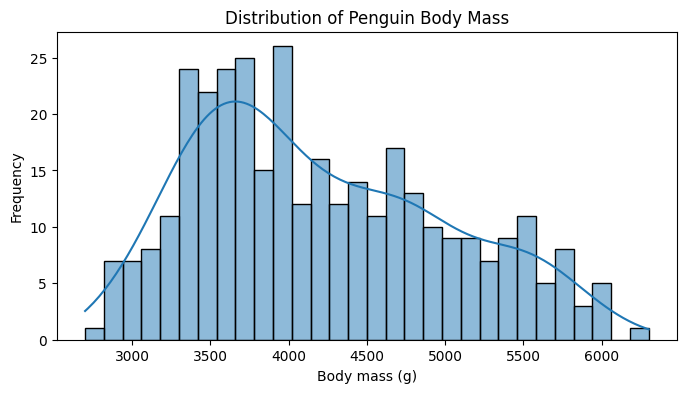

Mean: 4201.8 g
Median: 4050.0 g
分布右偏（正偏）


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['body_mass_g'].dropna(), bins=30, kde=True)
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Frequency")
plt.show()

mean_bm = df['body_mass_g'].mean()
median_bm = df['body_mass_g'].median()
print(f"Mean: {mean_bm:.1f} g")
print(f"Median: {median_bm:.1f} g")
if mean_bm > median_bm:
    print("分布右偏（正偏）")
elif mean_bm < median_bm:
    print("分布左偏（负偏）")
else:
    print("对称")

均值 > 中位数，直方图显示右侧有一个较长的尾巴（主要是体重较大的 Gentoo 企鹅）。由于右偏，中位数更能代表“典型”企鹅的体重，因为它不受少数大体重个体的影响。因此我会选择报告中位数。

## 练习3

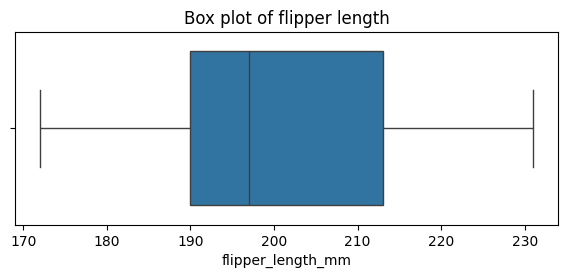

Number of outliers: 0


In [3]:
def find_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < low) | (s > high)]

plt.figure(figsize=(7,2.5))
sns.boxplot(x=df['flipper_length_mm'])
plt.title("Box plot of flipper length")
plt.show()

outliers = find_outliers(df['flipper_length_mm'])
print(f"Number of outliers: {len(outliers)}")

1.5×IQR 规则是为了识别相对于主体数据显著偏离的单个点。在双峰分布中，两个峰都是数据的“主体”部分，它们之间的间隔不足以使其中一个峰中的点被判定为离群值（因为它们没有超过 Q3+1.5×IQR 或低于 Q1-1.5×IQR）。该规则无法检测出“多组正常数据”的情况，因此双峰分布需要靠直方图或密度图来发现，而不是离群值检测。教训：离群值规则只能捕获“罕见的极端点”，不能识别出固有的分组结构。

## 练习4

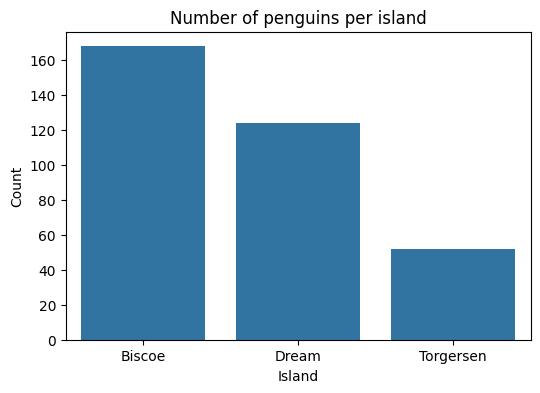

Proportions:
island
Biscoe       0.488
Dream        0.360
Torgersen    0.151
Name: proportion, dtype: float64


In [4]:
# 频数条形图
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='island', order=df['island'].value_counts().index)
plt.title("Number of penguins per island")
plt.xlabel("Island")
plt.ylabel("Count")
plt.show()

# 比例
proportions = df['island'].value_counts(normalize=True).round(3)
print("Proportions:")
print(proportions)

Biscoe 岛拥有最多的企鹅（约 48.8%），Dream 岛次之（36.0%），Torgersen 岛最少（15.1%）。

## 练习5

In [5]:
numeric_cols = df.select_dtypes(include='number').columns
cv_data = {}
for col in numeric_cols:
    s = df[col].dropna()
    cv = s.std() / s.mean()
    cv_data[col] = cv

cv_series = pd.Series(cv_data).sort_values(ascending=False)
print("Coefficient of variation (std/mean):")
print(cv_series.round(3))

Coefficient of variation (std/mean):
body_mass_g          0.191
bill_length_mm       0.124
bill_depth_mm        0.115
flipper_length_mm    0.070
dtype: float64


body_mass_g 的 CV 最大（约 0.191），说明体重的相对变异最大。原始标准差不能直接比较不同量纲的变量（例如喙长 ~40mm，体重 ~4000g），而 CV 是无量纲的，表示相对于其均值的离散程度，因此适合比较不同测量尺度的变量。

## 练习6

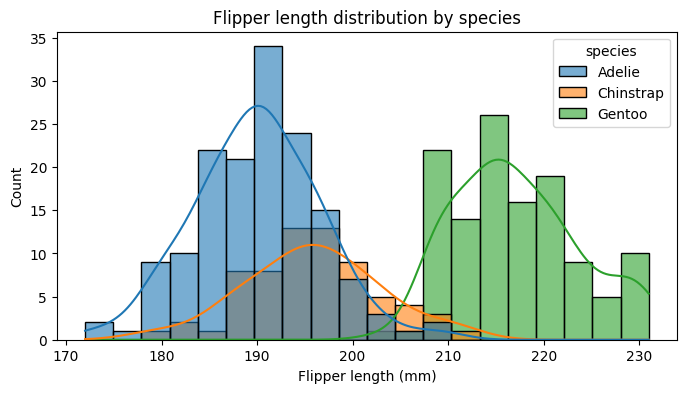

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='flipper_length_mm', hue='species', bins=20, alpha=0.6, kde=True)
plt.title("Flipper length distribution by species")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Count")
plt.show()